In [2]:
import pandas as pd
import numpy as np

nav = pd.read_csv("../data/raw/02_nav_history.csv")

nav.columns = nav.columns.str.strip().str.lower()

print(nav.columns.tolist())
print(nav.head())

['amfi_code', 'date', 'nav']
   amfi_code        date      nav
0     119551  2022-01-03  54.3856
1     119551  2022-01-04  54.3474
2     119551  2022-01-05  54.6869
3     119551  2022-01-06  55.4550
4     119551  2022-01-07  55.3692


In [3]:
nav["date"] = pd.to_datetime(nav["date"])
nav = nav.sort_values(["amfi_code", "date"])

nav["daily_return"] = nav.groupby("amfi_code")["nav"].pct_change()

var_cvar_results = []

for amfi_code, group in nav.groupby("amfi_code"):
    returns = group["daily_return"].dropna()

    var_95 = returns.quantile(0.05)
    cvar_95 = returns[returns <= var_95].mean()

    var_cvar_results.append({
        "amfi_code": amfi_code,
        "var_95_pct": var_95 * 100,
        "cvar_95_pct": cvar_95 * 100
    })

var_cvar_df = pd.DataFrame(var_cvar_results)

print(var_cvar_df.head())
print("\nFunds:", len(var_cvar_df))
print("Missing VaR values:", var_cvar_df["var_95_pct"].isna().sum())
print("Missing CVaR values:", var_cvar_df["cvar_95_pct"].isna().sum())

   amfi_code  var_95_pct  cvar_95_pct
0     100016   -1.436364    -1.806021
1     100025   -0.379325    -0.499376
2     100033   -1.903354    -2.345576
3     101206   -1.328166    -1.743943
4     101207   -2.602125    -3.245906

Funds: 40
Missing VaR values: 0
Missing CVaR values: 0


        date  amfi_code                                    scheme_name  \
0 2022-01-03     148567  Mirae Asset Large Cap Fund - Regular - Growth   
1 2022-01-04     148567  Mirae Asset Large Cap Fund - Regular - Growth   
2 2022-01-05     148567  Mirae Asset Large Cap Fund - Regular - Growth   
3 2022-01-06     148567  Mirae Asset Large Cap Fund - Regular - Growth   
4 2022-01-07     148567  Mirae Asset Large Cap Fund - Regular - Growth   

   rolling_sharpe_90  
0                NaN  
1                NaN  
2                NaN  
3                NaN  
4                NaN  

Funds: 5
Missing Rolling Sharpe values: 450


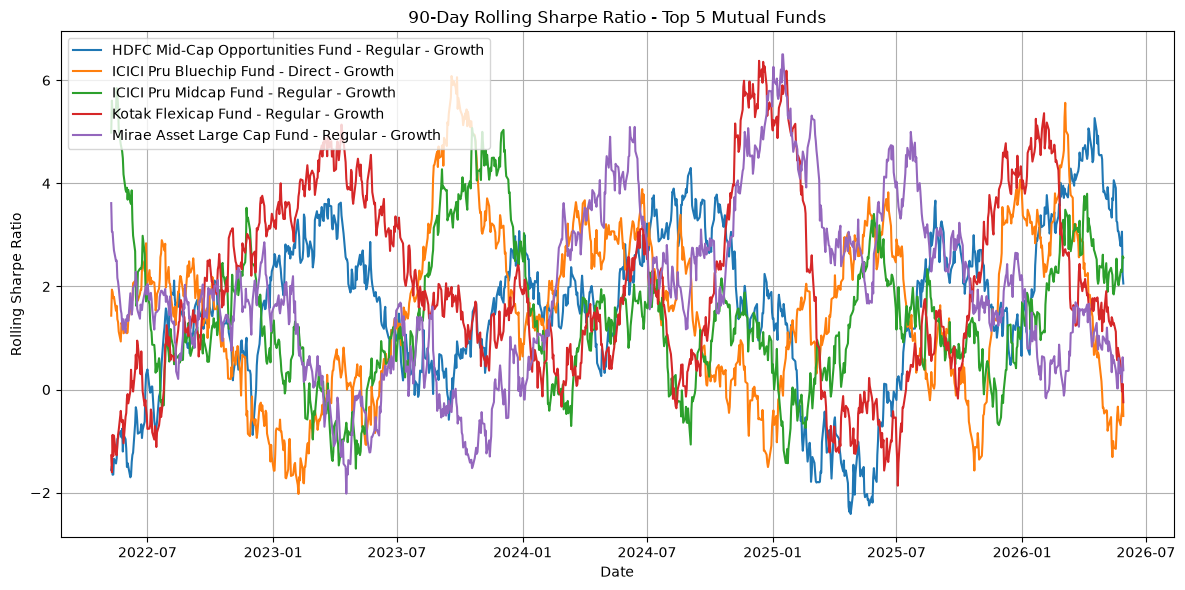

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

nav["date"] = pd.to_datetime(nav["date"])

scorecard = pd.read_csv("../reports/fund_scorecard.csv")

top5_codes = scorecard.head(5)["amfi_code"].tolist()

rolling_results = []

for amfi_code in top5_codes:
    group = nav[nav["amfi_code"] == amfi_code].sort_values("date").copy()

    group["daily_return"] = group["nav"].pct_change()

    group["rolling_sharpe_90"] = (
        group["daily_return"].rolling(90).mean()
        / group["daily_return"].rolling(90).std()
    ) * np.sqrt(252)

    scheme_name = scorecard.loc[
        scorecard["amfi_code"] == amfi_code,
        "scheme_name"
    ].iloc[0]

    group["scheme_name"] = scheme_name

    rolling_results.append(
        group[["date", "amfi_code", "scheme_name", "rolling_sharpe_90"]]
    )

rolling_sharpe_df = pd.concat(
    rolling_results,
    ignore_index=True
)

print(rolling_sharpe_df.head())

print("\nFunds:", rolling_sharpe_df["amfi_code"].nunique())

print(
    "Missing Rolling Sharpe values:",
    rolling_sharpe_df["rolling_sharpe_90"].isna().sum()
)

plt.figure(figsize=(12, 6))

for scheme_name, group in rolling_sharpe_df.groupby("scheme_name"):
    plt.plot(
        group["date"],
        group["rolling_sharpe_90"],
        label=scheme_name
    )

plt.title("90-Day Rolling Sharpe Ratio - Top 5 Mutual Funds")
plt.xlabel("Date")
plt.ylabel("Rolling Sharpe Ratio")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig("../reports/rolling_sharpe_chart.png", dpi=150)

plt.show()

In [6]:
transactions = pd.read_csv("../data/raw/08_investor_transactions.csv")

transactions.columns = transactions.columns.str.strip().str.lower()

print(transactions.columns.tolist())
print(transactions.head())
print("\nTransactions:", len(transactions))

['investor_id', 'transaction_date', 'amfi_code', 'transaction_type', 'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender', 'annual_income_lakh', 'payment_mode', 'kyc_status']
  investor_id transaction_date  amfi_code transaction_type  amount_inr  \
0   INV003054       2024-01-01     119092              SIP        1834   
1   INV002952       2024-01-01     148567       Redemption      392882   
2   INV003420       2024-01-01     118636              SIP         912   
3   INV003436       2024-01-01     118634              SIP        1102   
4   INV004691       2024-01-01     119094          Lumpsum        8682   

         state       city city_tier age_group  gender  annual_income_lakh  \
0    Telangana  Hyderabad       T30       56+  Female                77.1   
1       Punjab   Amritsar       B30     18-25    Male                 7.1   
2      Haryana  Faridabad       B30     36-45    Male                47.2   
3  Maharashtra     Mumbai       T30     36-45  Female      

In [7]:
transactions["transaction_date"] = pd.to_datetime(
    transactions["transaction_date"]
)

transactions["first_transaction_year"] = (
    transactions.groupby("investor_id")["transaction_date"]
    .transform("min")
    .dt.year
)

investment_transactions = transactions[
    transactions["transaction_type"].isin(["SIP", "Lumpsum"])
].copy()

cohort_summary = (
    investment_transactions
    .groupby("first_transaction_year")
    .agg(
        investors=("investor_id", "nunique"),
        avg_sip_amount=("amount_inr", lambda x:
                        investment_transactions.loc[
                            x.index,
                            "transaction_type"
                        ].eq("SIP").mul(x).sum()
                        / max(
                            investment_transactions.loc[
                                x.index,
                                "transaction_type"
                            ].eq("SIP").sum(),
                            1
                        )),
        total_invested=("amount_inr", "sum")
    )
    .reset_index()
)

top_funds = (
    investment_transactions
    .groupby(["first_transaction_year", "amfi_code"])
    .size()
    .reset_index(name="transaction_count")
    .sort_values(
        ["first_transaction_year", "transaction_count"],
        ascending=[True, False]
    )
    .drop_duplicates("first_transaction_year")
)

cohort_summary = cohort_summary.merge(
    top_funds[
        ["first_transaction_year", "amfi_code", "transaction_count"]
    ],
    on="first_transaction_year",
    how="left"
)

fund_names = transactions[
    ["amfi_code"]
].drop_duplicates()

fund_master = pd.read_csv("../data/raw/01_fund_master.csv")
fund_master.columns = fund_master.columns.str.strip().str.lower()

if "scheme_name" in fund_master.columns:
    cohort_summary = cohort_summary.merge(
        fund_master[["amfi_code", "scheme_name"]].drop_duplicates(),
        on="amfi_code",
        how="left"
    )

print(cohort_summary)

print("\nCohorts:", len(cohort_summary))
print(
    "Missing cohort values:",
    cohort_summary.isna().sum().sum()
)

   first_transaction_year  investors  avg_sip_amount  total_invested  \
0                    2024       4770    10996.885825      2258062304   
1                    2025        173    13505.209581        18992635   

   amfi_code  transaction_count  \
0     125498                752   
1     119599                 11   

                                         scheme_name  
0  HDFC Mid-Cap Opportunities Fund - Direct - Growth  
1          SBI Small Cap Fund - Direct Plan - Growth  

Cohorts: 2
Missing cohort values: 0


In [8]:
sip_transactions = transactions[
    transactions["transaction_type"] == "SIP"
].copy()

sip_transactions = sip_transactions.sort_values(
    ["investor_id", "transaction_date"]
)

sip_counts = (
    sip_transactions
    .groupby("investor_id")
    .size()
    .reset_index(name="sip_count")
)

eligible_investors = sip_counts[
    sip_counts["sip_count"] >= 6
]["investor_id"]

sip_eligible = sip_transactions[
    sip_transactions["investor_id"].isin(eligible_investors)
].copy()

print("Total SIP transactions:", len(sip_transactions))
print("Investors with 6+ SIPs:", len(eligible_investors))
print(sip_eligible.head())

Total SIP transactions: 19716
Investors with 6+ SIPs: 1362
      investor_id transaction_date  amfi_code transaction_type  amount_inr  \
4773    INV000004       2024-03-16     101208              SIP         960   
6418    INV000004       2024-04-11     119095              SIP       20602   
8271    INV000004       2024-05-09     120844              SIP         541   
12003   INV000004       2024-07-07     148569              SIP        9761   
28749   INV000004       2025-03-29     149324              SIP       14282   

        state        city city_tier age_group gender  annual_income_lakh  \
4773   Punjab  Chandigarh       T30     26-35   Male                20.0   
6418   Punjab  Chandigarh       T30     26-35   Male                20.0   
8271   Punjab  Chandigarh       T30     26-35   Male                20.0   
12003  Punjab  Chandigarh       T30     26-35   Male                20.0   
28749  Punjab  Chandigarh       T30     26-35   Male                20.0   

      payment_m

In [9]:
sip_eligible["days_since_previous_sip"] = (
    sip_eligible
    .groupby("investor_id")["transaction_date"]
    .diff()
    .dt.days
)

sip_continuity = (
    sip_eligible
    .groupby("investor_id")
    .agg(
        sip_count=("transaction_date", "count"),
        avg_gap_days=("days_since_previous_sip", "mean"),
        max_gap_days=("days_since_previous_sip", "max"),
        first_sip_date=("transaction_date", "min"),
        last_sip_date=("transaction_date", "max")
    )
    .reset_index()
)

sip_continuity["continuity_status"] = np.where(
    sip_continuity["max_gap_days"] > 35,
    "at-risk",
    "regular"
)

print(sip_continuity.head(10))

print("\nEligible investors:", len(sip_continuity))

print(
    "At-risk investors:",
    (sip_continuity["continuity_status"] == "at-risk").sum()
)

print(
    "Regular investors:",
    (sip_continuity["continuity_status"] == "regular").sum()
)

print(
    "\nMissing average gap values:",
    sip_continuity["avg_gap_days"].isna().sum()
)

  investor_id  sip_count  avg_gap_days  max_gap_days first_sip_date  \
0   INV000004          6     85.400000         265.0     2024-03-16   
1   INV000008          6     70.400000         165.0     2024-05-27   
2   INV000010          6     64.800000         139.0     2024-04-11   
3   INV000011          7     40.166667         125.0     2024-01-03   
4   INV000012          8     57.000000         132.0     2024-03-27   
5   INV000013          7     55.333333         104.0     2024-04-18   
6   INV000014          7     75.333333         128.0     2024-02-23   
7   INV000023          8     58.571429         115.0     2024-03-21   
8   INV000028          6     93.600000         238.0     2024-02-07   
9   INV000029          7     60.666667          96.0     2024-05-16   

  last_sip_date continuity_status  
0    2025-05-17           at-risk  
1    2025-05-14           at-risk  
2    2025-03-01           at-risk  
3    2024-08-31           at-risk  
4    2025-04-30           at-risk  
5 

In [10]:
fund_scorecard = pd.read_csv("../reports/fund_scorecard.csv")

fund_scorecard.columns = fund_scorecard.columns.str.strip().str.lower()

print(fund_scorecard.columns.tolist())
print(fund_scorecard.head())

['amfi_code', 'cagr_3yr', 'sharpe_ratio', 'alpha', 'max_drawdown_pct', 'scheme_name', 'expense_ratio_pct', 'return_rank', 'sharpe_rank', 'alpha_rank', 'expense_rank_inverse', 'drawdown_rank_inverse', 'fund_score', 'rank']
   amfi_code  cagr_3yr  sharpe_ratio     alpha  max_drawdown_pct  \
0     148567  0.339920      1.448291  0.269838        -11.265729   
1     120505  0.317692      1.180101  0.292636        -18.188514   
2     120843  0.295751      1.306744  0.273305        -12.973968   
3     100033  0.324340      1.093699  0.271954        -16.217209   
4     120504  0.324789      1.026524  0.211948        -12.588276   

                                         scheme_name  expense_ratio_pct  \
0      Mirae Asset Large Cap Fund - Regular - Growth               1.46   
1           ICICI Pru Midcap Fund - Regular - Growth               1.36   
2             Kotak Flexicap Fund - Regular - Growth               1.45   
3  HDFC Mid-Cap Opportunities Fund - Regular - Gr...               1.

In [11]:
print("Max Drawdown Range:")
print("Minimum:", fund_scorecard["max_drawdown_pct"].min())
print("Maximum:", fund_scorecard["max_drawdown_pct"].max())

print("\nMax Drawdown Values:")
print(
    fund_scorecard[
        ["scheme_name", "max_drawdown_pct", "sharpe_ratio"]
    ].sort_values("max_drawdown_pct")
)

Max Drawdown Range:
Minimum: -52.57422117012851
Maximum: -0.0977314004592555

Max Drawdown Values:
                                          scheme_name  max_drawdown_pct  \
34          SBI Small Cap Fund - Direct Plan - Growth        -52.574221   
37             Axis Small Cap Fund - Regular - Growth        -51.677754   
36             ABSL Small Cap Fund - Regular - Growth        -35.446916   
11              DSP Small Cap Fund - Regular - Growth        -31.171900   
9          SBI Small Cap Fund - Regular Plan - Growth        -28.706006   
39                UTI Mid Cap Fund - Regular - Growth        -28.001124   
38          HDFC Top 100 Fund - Regular Plan - Growth        -24.734441   
33      Kotak Emerging Equity Fund - Regular - Growth        -24.003511   
28     Nippon India Small Cap Fund - Regular - Growth        -23.344886   
22               Axis Bluechip Fund - Direct - Growth        -21.751396   
23              UTI Flexi Cap Fund - Regular - Growth        -21.539827   
2

In [12]:
fund_scorecard["drawdown_risk"] = fund_scorecard["max_drawdown_pct"].abs()

fund_scorecard["risk_percentile"] = (
    fund_scorecard["drawdown_risk"].rank(pct=True)
)

fund_scorecard["risk_grade"] = np.select(
    [
        fund_scorecard["risk_percentile"] <= 1/3,
        fund_scorecard["risk_percentile"] <= 2/3
    ],
    [
        "Low",
        "Moderate"
    ],
    default="High"
)

def recommend_funds(risk_appetite):
    risk_appetite = risk_appetite.strip().title()

    if risk_appetite not in ["Low", "Moderate", "High"]:
        print("Risk appetite must be Low, Moderate, or High.")
        return

    recommendations = (
        fund_scorecard[
            fund_scorecard["risk_grade"] == risk_appetite
        ]
        .sort_values("sharpe_ratio", ascending=False)
        .head(3)
        [
            [
                "scheme_name",
                "risk_grade",
                "sharpe_ratio",
                "cagr_3yr",
                "max_drawdown_pct",
                "fund_score"
            ]
        ]
        .reset_index(drop=True)
    )

    recommendations.index = recommendations.index + 1

    print(f"\nTop 3 Fund Recommendations for {risk_appetite} Risk Appetite:")
    print(recommendations)

    return recommendations

low_risk = recommend_funds("Low")
moderate_risk = recommend_funds("Moderate")
high_risk = recommend_funds("High")


Top 3 Fund Recommendations for Low Risk Appetite:
                                     scheme_name risk_grade  sharpe_ratio  \
1  Mirae Asset Large Cap Fund - Regular - Growth        Low      1.448291   
2         Kotak Flexicap Fund - Regular - Growth        Low      1.306744   
3  ABSL Frontline Equity Fund - Regular - Growth        Low      1.027213   

   cagr_3yr  max_drawdown_pct  fund_score  
1  0.339920        -11.265729     86.2500  
2  0.295751        -12.973968     82.0000  
3  0.289602        -11.291596     68.1875  

Top 3 Fund Recommendations for Moderate Risk Appetite:
                                     scheme_name risk_grade  sharpe_ratio  \
1  Mirae Asset Tax Saver Fund - Regular - Growth   Moderate      1.234930   
2      SBI Bluechip Fund - Regular Plan - Growth   Moderate      1.208267   
3       ICICI Pru Midcap Fund - Regular - Growth   Moderate      1.180101   

   cagr_3yr  max_drawdown_pct  fund_score  
1  0.291714        -16.396743     73.6875  
2  0.304486

In [13]:
industry = pd.read_csv("../data/raw/06_industry_folio_count.csv")

industry.columns = industry.columns.str.strip().str.lower()

print(industry.columns.tolist())
print(industry.head())
print("\nRows:", len(industry))

['month', 'total_folios_crore', 'equity_folios_crore', 'debt_folios_crore', 'hybrid_folios_crore', 'others_folios_crore']
     month  total_folios_crore  equity_folios_crore  debt_folios_crore  \
0  2022-01               13.26                 9.28               1.86   
1  2022-04               13.91                 9.74               1.95   
2  2022-07               13.85                 9.69               1.94   
3  2022-10               14.12                 9.88               1.98   
4  2023-01               14.81                10.37               2.07   

   hybrid_folios_crore  others_folios_crore  
0                 0.80                 1.33  
1                 0.83                 1.39  
2                 0.83                 1.38  
3                 0.85                 1.41  
4                 0.89                 1.48  

Rows: 21


In [14]:
holdings = pd.read_csv("../data/raw/09_portfolio_holdings.csv")

holdings.columns = holdings.columns.str.strip().str.lower()

print(holdings.columns.tolist())
print(holdings.head())
print("\nRows:", len(holdings))

['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct', 'market_value_cr', 'current_price_inr', 'portfolio_date']
   amfi_code stock_symbol                stock_name       sector  weight_pct  \
0     119551    POWERGRID    Power Grid Corporation    Utilities       13.85   
1     119551     HDFCBANK             HDFC Bank Ltd      Banking       11.19   
2     119551       GRASIM     Grasim Industries Ltd  Diversified        9.90   
3     119551      DRREDDY  Dr. Reddy's Laboratories       Pharma        4.76   
4     119551   ASIANPAINT          Asian Paints Ltd       Paints       10.25   

   market_value_cr  current_price_inr portfolio_date  
0           737.09            6011.08     2025-12-31  
1            88.97            1074.65     2025-12-31  
2           208.45            5964.59     2025-12-31  
3           161.32            3748.82     2025-12-31  
4           725.90            1321.45     2025-12-31  

Rows: 322


In [15]:
holdings["weight_pct"] = pd.to_numeric(holdings["weight_pct"], errors="coerce")
holdings["sector"] = holdings["sector"].astype(str).str.strip()

sector_weights = (
    holdings.groupby(["amfi_code", "sector"])["weight_pct"]
    .sum()
    .reset_index()
)

hhi = (
    sector_weights.groupby("amfi_code")["weight_pct"]
    .apply(lambda x: ((x / x.sum()) ** 2).sum())
    .reset_index(name="sector_hhi")
)

hhi["hhi_0_10000"] = hhi["sector_hhi"] * 10000

hhi = hhi.sort_values("sector_hhi", ascending=False)

print("Sector HHI Concentration:")
print(hhi.head(10))

print("\nFunds analyzed:", len(hhi))
print("Highest HHI:", hhi["hhi_0_10000"].max())
print("Lowest HHI:", hhi["hhi_0_10000"].min())

hhi.to_csv("../reports/sector_hhi.csv", index=False)

Sector HHI Concentration:
    amfi_code  sector_hhi  hhi_0_10000
11     119092    0.296828  2968.284527
30     148569    0.255094  2550.939674
27     125498    0.253155  2531.550000
6      102887    0.251332  2513.322810
32     149323    0.241077  2410.766400
21     120505    0.238600  2385.995906
10     118635    0.237544  2375.442765
18     119599    0.232361  2323.612000
22     120506    0.231372  2313.717820
1      100033    0.227647  2276.474400

Funds analyzed: 34
Highest HHI: 2968.2845272225986
Lowest HHI: 1240.698629823985


# Day 4 — Advanced Analytics Insights

## 1. Risk and Downside Exposure
Historical VaR and CVaR were calculated for all 40 mutual fund schemes. The analysis provides a clear view of potential downside risk and tail-risk exposure across funds. CVaR is more conservative than VaR because it measures the average loss beyond the VaR threshold.

## 2. Rolling Risk-Adjusted Performance
The 90-day rolling Sharpe ratio was calculated for the top 5 funds and plotted over time. The results show that risk-adjusted performance changes significantly across market periods, with several funds reaching both strongly positive and negative Sharpe levels.

## 3. Investor Cohort Analysis
Investor transactions were grouped by first transaction year. The 2024 cohort contains 4,770 investors with approximately 225.81 crore total invested, while the 2025 cohort contains 173 investors with approximately 19.99 crore total invested. This shows that the 2024 cohort represents the larger investor base and investment volume.

## 4. SIP Continuity Risk
Among investors with 6 or more SIP transactions, 1,361 out of 1,362 eligible investors were classified as "at-risk" based on a gap greater than 35 days between SIP transactions. Only 1 investor was classified as regular, indicating a high level of SIP continuity risk in the analyzed dataset.

## 5. Portfolio Sector Concentration
Sector HHI analysis was performed across 34 funds using portfolio sector weights. HHI values ranged from approximately 1,240.70 to 2,968.28 on the 0–10,000 scale. Higher HHI indicates greater sector concentration, while lower HHI indicates a more diversified sector allocation.

In [16]:
var_cvar_df.to_csv("../reports/var_cvar_report.csv", index=False)

print("Saved: reports/var_cvar_report.csv")
print("Rows:", len(var_cvar_df))

Saved: reports/var_cvar_report.csv
Rows: 40


In [17]:
import pandas as pd

transactions = pd.read_csv("../data/processed/investor_transactions_cleaned.csv")
fund_master = pd.read_csv("../data/raw/01_fund_master.csv")

transactions["transaction_date"] = pd.to_datetime(
    transactions["transaction_date"],
    errors="coerce"
)

transactions["amount_inr"] = pd.to_numeric(
    transactions["amount_inr"],
    errors="coerce"
)

transactions = transactions.dropna(
    subset=["investor_id", "transaction_date", "amount_inr", "amfi_code"]
)

transactions["first_transaction_year"] = (
    transactions.groupby("investor_id")["transaction_date"]
    .transform("min")
    .dt.year
)

investor_cohort = transactions[
    transactions["transaction_type"].isin(["SIP", "Lumpsum"])
].copy()

cohort_summary = (
    investor_cohort.groupby("first_transaction_year")
    .agg(
        investors=("investor_id", "nunique"),
        total_invested=("amount_inr", "sum")
    )
    .reset_index()
)

sip_summary = (
    investor_cohort[
        investor_cohort["transaction_type"] == "SIP"
    ]
    .groupby("first_transaction_year")
    .agg(
        avg_sip_amount=("amount_inr", "mean")
    )
    .reset_index()
)

fund_preference = (
    investor_cohort
    .groupby(["first_transaction_year", "amfi_code"])["investor_id"]
    .nunique()
    .reset_index(name="investor_count")
)

top_funds = (
    fund_preference
    .sort_values(
        ["first_transaction_year", "investor_count"],
        ascending=[True, False]
    )
    .drop_duplicates("first_transaction_year")
)

top_funds = top_funds.merge(
    fund_master[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

top_funds = top_funds[
    ["first_transaction_year", "scheme_name"]
].rename(
    columns={"scheme_name": "top_fund_preference"}
)

cohort_summary = (
    cohort_summary
    .merge(
        sip_summary,
        on="first_transaction_year",
        how="left"
    )
    .merge(
        top_funds,
        on="first_transaction_year",
        how="left"
    )
)

cohort_summary["total_invested_crore"] = (
    cohort_summary["total_invested"] / 1e7
)

cohort_summary = cohort_summary[
    [
        "first_transaction_year",
        "investors",
        "avg_sip_amount",
        "total_invested_crore",
        "top_fund_preference"
    ]
].sort_values("first_transaction_year")

print("Investor Cohort Analysis")
print("=" * 80)
print(cohort_summary.to_string(index=False))

cohort_summary.to_csv(
    "../reports/investor_cohort_analysis.csv",
    index=False
)

print("\nSaved: reports/investor_cohort_analysis.csv")

Investor Cohort Analysis
 first_transaction_year  investors  avg_sip_amount  total_invested_crore                               top_fund_preference
                   2024       4770    10996.885825            225.806230 HDFC Mid-Cap Opportunities Fund - Direct - Growth
                   2025        173    13505.209581              1.899263         SBI Small Cap Fund - Direct Plan - Growth

Saved: reports/investor_cohort_analysis.csv


In [18]:
import pandas as pd

transactions = pd.read_csv("../data/processed/investor_transactions_cleaned.csv")

transactions["transaction_date"] = pd.to_datetime(
    transactions["transaction_date"],
    errors="coerce"
)

sip = transactions[
    transactions["transaction_type"].astype(str).str.strip().str.upper() == "SIP"
].copy()

sip = sip.dropna(
    subset=["investor_id", "transaction_date"]
)

sip = sip.sort_values(
    ["investor_id", "transaction_date"]
)

sip_counts = (
    sip.groupby("investor_id")
    .size()
    .reset_index(name="sip_transaction_count")
)

eligible_investors = sip_counts[
    sip_counts["sip_transaction_count"] >= 6
]["investor_id"]

sip_eligible = sip[
    sip["investor_id"].isin(eligible_investors)
].copy()

sip_eligible["gap_days"] = (
    sip_eligible
    .groupby("investor_id")["transaction_date"]
    .diff()
    .dt.days
)

sip_gap_summary = (
    sip_eligible
    .groupby("investor_id")
    .agg(
        sip_transaction_count=("transaction_date", "count"),
        avg_gap_days=("gap_days", "mean"),
        max_gap_days=("gap_days", "max")
    )
    .reset_index()
)

sip_gap_summary["continuity_status"] = (
    sip_gap_summary["avg_gap_days"]
    .apply(lambda x: "at-risk" if x > 35 else "regular")
)

at_risk_count = (
    sip_gap_summary["continuity_status"] == "at-risk"
).sum()

regular_count = (
    sip_gap_summary["continuity_status"] == "regular"
).sum()

total_eligible = len(sip_gap_summary)

at_risk_rate = (
    at_risk_count / total_eligible * 100
    if total_eligible > 0 else 0
)

regular_rate = (
    regular_count / total_eligible * 100
    if total_eligible > 0 else 0
)

print("SIP Continuity Analysis")
print("=" * 80)

print(f"Eligible investors (6+ SIP transactions): {total_eligible}")
print(f"At-risk investors (average gap > 35 days): {at_risk_count}")
print(f"Regular investors (average gap <= 35 days): {regular_count}")
print(f"At-risk rate: {at_risk_rate:.2f}%")
print(f"Regular rate: {regular_rate:.2f}%")

print("\nSIP Gap Summary:")
print(
    sip_gap_summary
    .sort_values("avg_gap_days", ascending=False)
    .head(10)
    .to_string(index=False)
)

sip_gap_summary.to_csv(
    "../reports/sip_continuity_analysis.csv",
    index=False
)

print("\nSaved: reports/sip_continuity_analysis.csv")

SIP Continuity Analysis
Eligible investors (6+ SIP transactions): 1362
At-risk investors (average gap > 35 days): 1332
Regular investors (average gap <= 35 days): 30
At-risk rate: 97.80%
Regular rate: 2.20%

SIP Gap Summary:
investor_id  sip_transaction_count  avg_gap_days  max_gap_days continuity_status
  INV001890                      6         102.6         207.0           at-risk
  INV001156                      6         102.4         175.0           at-risk
  INV004296                      6         102.2         304.0           at-risk
  INV003325                      6         101.0         155.0           at-risk
  INV000522                      6         100.8         309.0           at-risk
  INV000608                      6         100.2         324.0           at-risk
  INV001883                      6          99.2         203.0           at-risk
  INV002166                      6          99.2         248.0           at-risk
  INV001367                      6          99

# Advanced Analytics Insights

## 1. Risk and Downside Exposure
Historical 95% VaR and CVaR were calculated for all 40 mutual fund schemes. The highest VaR values (closest to zero) were observed for AMFI codes 120507 (-0.022157%), 101208 (-0.026866%), and 120844 (-0.028479%), while AMFI code 118636 recorded a VaR of -0.380415%. The lowest VaR values were observed for AMFI codes 119599 (-2.685944%) and 119095 (-2.618842%), indicating comparatively higher downside exposure.

## 2. Rolling Risk-Adjusted Performance
A 90-day rolling Sharpe ratio was calculated using daily returns and annualized using √252. The analysis was performed for five key funds and visualized over time. The rolling Sharpe analysis highlights how risk-adjusted performance changes across different market periods rather than remaining constant.

## 3. Investor Cohort and Investment Behaviour
Investor transactions were grouped by first transaction year. The 2024 cohort contained 4,770 investors with an average SIP amount of approximately ₹10,996.89 and total investment of approximately ₹225.81 crore. The 2025 cohort contained 173 investors with an average SIP amount of approximately ₹13,505.21 and total investment of approximately ₹1.90 crore. The 2024 cohort therefore represents the larger investor base and the majority of total investment in the analysed dataset.

## 4. SIP Continuity and At-Risk Investors
Among investors with at least six SIP transactions, 1,362 investors were eligible for continuity analysis. Based on the average gap between SIP transaction dates, 1,332 investors (97.80%) were classified as at-risk because their average SIP gap exceeded 35 days, while 30 investors (2.20%) were classified as regular. This indicates a high level of SIP continuity risk in the analysed dataset.

## 5. Portfolio Sector Concentration
Sector HHI analysis was performed across 34 funds. HHI values ranged from approximately 1,240.70 to 2,968.28 on the 0–10,000 scale. The highest concentration was observed for AMFI code 119092 with an HHI of approximately 2,968.28, while AMFI code 102886 had the lowest HHI at approximately 1,240.70. Higher HHI indicates greater sector concentration, whereas lower HHI indicates relatively more diversified sector allocation.